<h1> Libraries and Reproducibility</h1>

Import the required libraries for data processing, visualization, and deep learning. A fixed random seed is set across Python, NumPy, TensorFlow, and PyTorch to ensure reproducible results.

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import random
import tensorflow as tf
import torch

In [2]:
# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# PyTorch CPU & GPU
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Make CuDNN deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

<h1> Data Loading </h1>

Load the experimental datasets from pickle files.

In [3]:
path = Path.home() / "OneDrive - Université De Technologie De Belfort-Montbeliard" / "UTBM" / "Data" / "PEMFC_BZ100-13-5 aging data" / "Data"
Df2 = pickle.load(open(path / "FC2_Ageing.pkl", "rb"))
Df2=Df2.sort_values("Time (h)") # sort the data
Df2

,Time (h),U1 (V),U2 (V),U3 (V),U4 (V),U5 (V),Utot (V),J (A/cm²),I (A),TinH2 (°C),...,PinAIR (mbara),PoutAIR (mbara),PoutH2 (mbara),PinH2 (mbara),DinH2 (l/mn),DoutH2 (l/mn),DinAIR (l/mn),DoutAIR (l/mn),DWAT (l/mn),HrAIRFC (%)
0,0.000000,0.669,0.665,0.664,0.666,0.661,3.325,0.69978,69.978,24.537,...,1299.531,1263.399,1296.308,1282.863,4.793,2.128,23.038,21.329,2.014,54.351
1,0.008389,0.669,0.665,0.663,0.666,0.661,3.324,0.69973,69.973,24.552,...,1299.303,1263.114,1295.453,1281.952,4.805,2.126,23.036,21.327,2.020,53.213
2,0.016778,0.669,0.666,0.664,0.667,0.662,3.328,0.69968,69.968,24.547,...,1301.010,1264.878,1295.111,1281.382,4.795,2.110,23.038,21.329,2.016,52.454
3,0.025169,0.670,0.667,0.665,0.666,0.662,3.330,0.69963,69.963,24.549,...,1299.303,1263.399,1295.453,1281.154,4.795,2.126,23.036,21.329,2.008,51.758
4,0.033559,0.672,0.667,0.664,0.666,0.662,3.331,0.69973,69.973,24.549,...,1299.701,1264.537,1295.453,1281.154,4.793,2.129,23.039,21.331,2.004,51.613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126714,1020.502744,0.635,0.632,0.629,0.627,0.619,3.142,0.70168,70.168,28.345,...,1300.896,1267.951,1297.677,1284.287,4.796,2.068,23.036,21.065,2.013,52.285
126715,1020.511135,0.636,0.633,0.630,0.629,0.619,3.147,0.70159,70.159,28.349,...,1301.579,1268.122,1301.612,1288.616,4.793,2.081,23.038,20.991,2.014,52.197
126716,1020.519526,0.637,0.633,0.629,0.628,0.619,3.146,0.70164,70.164,28.339,...,1301.351,1268.976,1304.635,1291.350,4.794,2.110,23.038,21.065,2.014,52.073
126717,1020.527915,0.637,0.633,0.630,0.627,0.619,3.146,0.70164,70.164,28.330,...,1299.986,1267.667,1303.494,1290.496,4.802,2.171,23.038,20.995,1.986,52.064


## Raw Signal Visualization

Visualize the voltage (`Utot (V)`) and current (`Current (A)`) signals for an example test case before preprocessing.

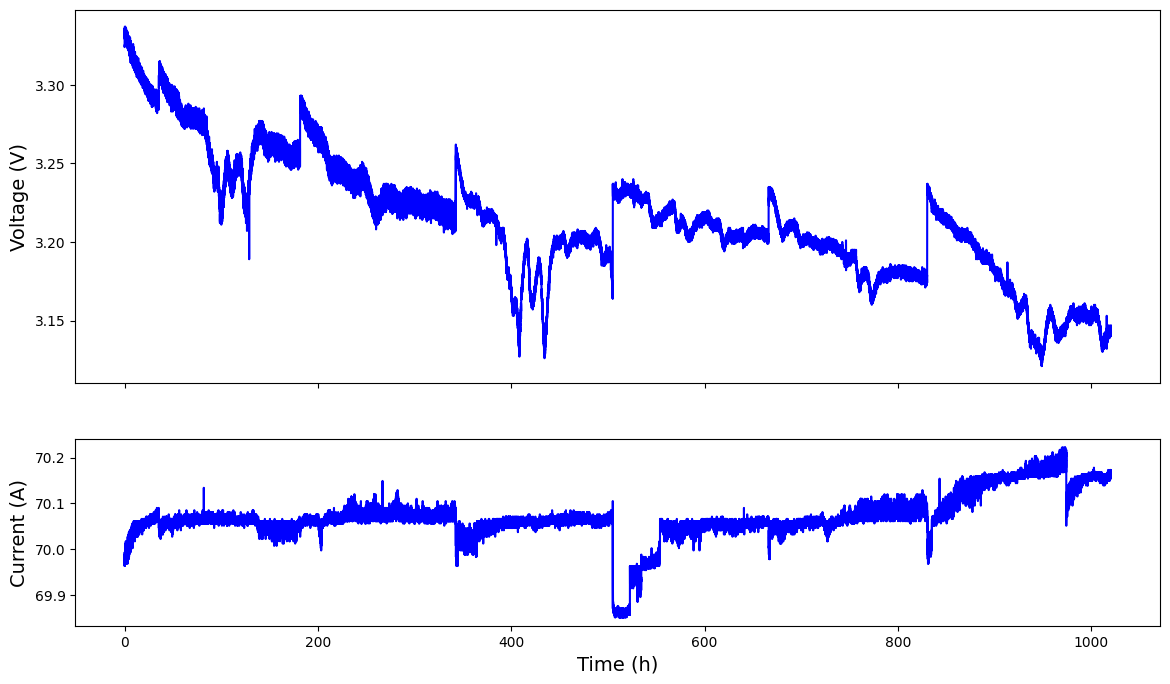

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
ax[0].plot (Df2['Time (h)'], Df2['Utot (V)'],color='blue')
ax[0].set_ylabel("Voltage (V)", size=14)
ax[1].plot(Df2['Time (h)'], Df2["I (A)"], color='blue')
ax[1].set_ylabel("Current (A)", size=14)
ax[1].set_xlabel("Time (h)", size=14)
plt.show()

## Hourly Data Resampling

Convert the measurements to hourly intervals using interpolation.

In [5]:
def resample_by_hour(df):
    df = df.groupby("Time (h)", as_index=False).mean()
    max_hour = int(df["Time (h)"].max())
    T = np.arange(1, max_hour +1,1)
    cols = df.select_dtypes(include=[np.number]).columns.drop("Time (h)")
    new = {"T(h)": T}
    for c in cols:
        new[c] = np.interp(T, df["Time (h)"], df[c])

    return pd.DataFrame(new)

df2 = resample_by_hour(Df2)
df2

,T(h),U1 (V),U2 (V),U3 (V),U4 (V),U5 (V),Utot (V),J (A/cm²),I (A),TinH2 (°C),...,PinAIR (mbara),PoutAIR (mbara),PoutH2 (mbara),PinH2 (mbara),DinH2 (l/mn),DoutH2 (l/mn),DinAIR (l/mn),DoutAIR (l/mn),DWAT (l/mn),HrAIRFC (%)
0,1,0.671000,0.668807,0.666000,0.667000,0.662000,3.334807,0.699938,69.993772,24.673122,...,1302.463117,1268.090685,1301.699975,1288.854997,4.799842,2.109965,23.069476,21.331000,1.981193,52.038936
1,2,0.671000,0.667000,0.664772,0.667000,0.661386,3.331158,0.700016,70.001596,24.810333,...,1302.108309,1267.675078,1300.933001,1287.981616,4.794228,2.105684,23.036000,21.327316,1.959000,51.976825
2,3,0.671000,0.665842,0.664842,0.666421,0.661421,3.329527,0.699911,69.991103,24.849630,...,1297.722854,1263.650317,1302.479501,1290.076087,4.793579,2.117840,23.037736,21.302359,2.043842,51.960089
3,4,0.671000,0.667772,0.663000,0.665772,0.660000,3.327543,0.700281,70.028141,24.798000,...,1300.640671,1266.666717,1299.075127,1285.714104,4.794000,2.109000,23.035543,21.329457,2.039913,52.042946
4,5,0.670000,0.666035,0.662035,0.664000,0.659965,3.322035,0.700024,70.002353,24.734647,...,1301.346973,1267.502041,1300.234364,1287.584307,4.793071,2.120834,23.034141,21.264929,2.027000,52.267438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015,1016,0.636000,0.631695,0.630391,0.627695,0.618000,3.143782,0.701555,70.155523,29.332346,...,1301.058804,1268.839715,1304.084452,1291.919913,4.795391,2.091752,23.037391,21.064391,1.979564,52.345542
1016,1017,0.634498,0.632000,0.627498,0.626498,0.617498,3.137990,0.701590,70.159000,28.650498,...,1299.729581,1267.438378,1297.722750,1284.872778,4.793493,2.056946,23.034995,21.065000,1.990990,52.503710
1017,1018,0.635690,0.633000,0.629000,0.626690,0.618690,3.143071,0.701575,70.157452,28.340954,...,1299.994107,1267.467995,1304.372019,1291.981919,4.793000,2.069000,23.036000,21.046113,1.976289,52.142427
1018,1019,0.635000,0.632000,0.629000,0.627117,0.619000,3.142117,0.701590,70.159000,28.328300,...,1300.621414,1267.920481,1295.812381,1282.374567,4.793883,2.127050,23.037533,21.027019,2.001000,52.354741


## Signal Visualization

Visualize the hourly voltage and current profiles of the fuel cell.

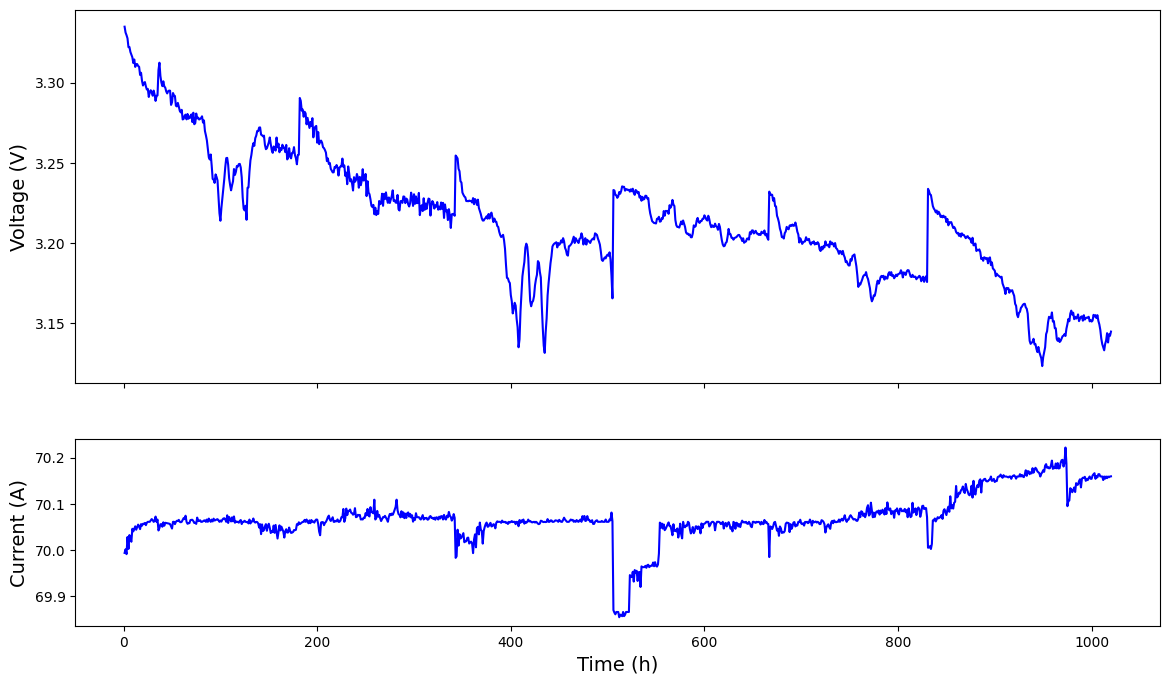

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1], sharex=True)
ax[0].plot (df2['T(h)'], df2['Utot (V)'],color='blue')
ax[0].set_ylabel("Voltage (V)", size=14)
ax[1].plot(df2['T(h)'], df2["I (A)"], color='blue')
ax[1].set_ylabel("Current (A)", size=14)
ax[1].set_xlabel("Time (h)", size=14)
plt.show()

## Target Preparation

Create the one-step-ahead prediction target by shifting the voltage signal and removing missing values.

In [7]:
DF = df2.drop(columns=["U1 (V)", "U2 (V)", "U3 (V)", "U4 (V)", "U5 (V)", "I (A)"])
DF["Utot_plus_1"] = DF["Utot (V)"].shift(-1)
DF = DF.dropna()
DF

,T(h),Utot (V),J (A/cm²),TinH2 (°C),ToutH2 (°C),TinAIR (°C),ToutAIR (°C),TinWAT (°C),ToutWAT (°C),PinAIR (mbara),PoutAIR (mbara),PoutH2 (mbara),PinH2 (mbara),DinH2 (l/mn),DoutH2 (l/mn),DinAIR (l/mn),DoutAIR (l/mn),DWAT (l/mn),HrAIRFC (%),Utot_plus_1
0,1,3.334807,0.699938,24.673122,37.746145,43.312141,51.204071,53.766650,55.450386,1302.463117,1268.090685,1301.699975,1288.854997,4.799842,2.109965,23.069476,21.331000,1.981193,52.038936,3.331158
1,2,3.331158,0.700016,24.810333,37.507158,43.098737,51.180264,53.747877,55.476930,1302.108309,1267.675078,1300.933001,1287.981616,4.794228,2.105684,23.036000,21.327316,1.959000,51.976825,3.329527
2,3,3.329527,0.699911,24.849630,37.577954,43.294951,51.215478,53.702628,55.441101,1297.722854,1263.650317,1302.479501,1290.076087,4.793579,2.117840,23.037736,21.302359,2.043842,51.960089,3.327543
3,4,3.327543,0.700281,24.798000,37.303424,43.300739,51.319521,53.752630,55.490467,1300.640671,1266.666717,1299.075127,1285.714104,4.794000,2.109000,23.035543,21.329457,2.039913,52.042946,3.322035
4,5,3.322035,0.700024,24.734647,37.730882,43.234821,51.216505,53.681187,55.378891,1301.346973,1267.502041,1300.234364,1287.584307,4.793071,2.120834,23.034141,21.264929,2.027000,52.267438,3.322158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,1015,3.139223,0.701590,29.333558,40.027944,44.152228,51.424116,53.778530,55.488507,1302.102725,1269.323513,1296.693740,1283.969361,4.793223,2.127665,23.038000,21.068777,1.986777,52.060348,3.143782
1015,1016,3.143782,0.701555,29.332346,39.862350,44.165526,51.363267,53.712334,55.449816,1301.058804,1268.839715,1304.084452,1291.919913,4.795391,2.091752,23.037391,21.064391,1.979564,52.345542,3.137990
1016,1017,3.137990,0.701590,28.650498,39.430365,44.433970,51.136985,53.437718,55.384369,1299.729581,1267.438378,1297.722750,1284.872778,4.793493,2.056946,23.034995,21.065000,1.990990,52.503710,3.143071
1017,1018,3.143071,0.701575,28.340954,39.343589,44.249787,51.163539,53.684665,55.492736,1299.994107,1267.467995,1304.372019,1291.981919,4.793000,2.069000,23.036000,21.046113,1.976289,52.142427,3.142117


## Train-Test Split

Split the dataset into training (70%) and testing (30%) subsets while preserving the temporal order of the measurements.

In [8]:
Trate = 0.7

Train = DF.iloc[0:int(len(DF)*Trate)]

Test = DF.iloc[int(len(DF)*Trate):]

print(len(Train), len(Test))

X_tr = Train.drop(columns=["Utot_plus_1"]).values
Y_tr = Train ["Utot_plus_1"].values.reshape(-1, 1)

X_ts = Test.drop(columns=["Utot_plus_1"]).values
Y_ts = Test ["Utot_plus_1"].values.reshape(-1, 1)

713 306


## Data Normalization

Normalize the input features and target variable using Min-Max scaling. The scalers are fitted on the training set and then applied to the test set to avoid data leakage.

The normalized inputs are finally reshaped into the format required by the deep learning models.

In [9]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_tr_scaled = scaler_x.fit_transform(X_tr)
X_ts_scaled = scaler_x.transform(X_ts)

Ytr = scaler_y.fit_transform(Y_tr)
Yts = scaler_y.transform(Y_ts)

Xtr = X_tr_scaled.reshape(X_tr_scaled.shape[0], 1, 19)
Xts= X_ts_scaled.reshape(X_ts_scaled.shape[0], 1, 19)

## LSTM-self-attention Model

Hybrid architecture combining LSTM layers and self-attention for voltage prediction.

In [10]:
import torch.nn as nn

class LSTM_TF(nn.Module):
    def __init__(self, input_dim, seq_len):
        super(LSTM_TF, self).__init__()

        self.seq_len = seq_len

        # ----- Step 1: LSTM block -----
        self.lstm1 = nn.LSTM(
            input_size=input_dim,
            hidden_size=256,
            batch_first=True,
            num_layers=1
        )

        self.lstm2 = nn.LSTM(
            input_size=256,
            hidden_size=256,
            batch_first=True,
            num_layers=1
        )

        # ----- Step 2: Multi-head self-attention -----
        # PyTorch MHA uses "embed_dim" = num_heads * head_dim
        embed_dim = 256  # 32*8
        self.attention_proj = nn.Linear(input_dim, embed_dim)

        self.mha = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=4,
            dropout=0,
            batch_first=True
        )

        # Concatenated dimension =  256 + 192
        self.post_cat_dim = 256 + embed_dim 

        # ----- Step 3–4: Dense layers -----
        self.fc1 = nn.Linear(self.post_cat_dim, 128)
        self.dropout = nn.Dropout(0)
        self.out = nn.Linear(128, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)

        # ----- LSTM block -----
        x1, _ = self.lstm1(x)  # (B, L, 256)
        x1, _ = self.lstm2(x1) # (B, L, 256)

        # ----- Transformer block -----
        attn_input = self.attention_proj(x)  # (B, L, 192)
        attn_output, _ = self.mha(attn_input, attn_input, attn_input)

        # Concatenate features along last axis
        x_cat = torch.cat([x1, attn_output], dim=-1)  # (B, L, 448)

        # Flatten
        x_pool = torch.mean(x_cat, dim=1)

        # Dense layers
        x_dense = torch.relu(self.fc1(x_pool))
        x_dense = self.dropout(x_dense)

        return self.out(x_dense)

In [11]:
# Model Summary
seq_len  = Xtr.shape[1]
input_dim = Xtr.shape[2]

model = LSTM_TF(input_dim=input_dim, seq_len=seq_len)
print(model)

from torchinfo import summary
summary(model, input_size=(1, seq_len, input_dim))

LSTM_TF(
  (lstm1): LSTM(19, 256, batch_first=True)
  (lstm2): LSTM(256, 256, batch_first=True)
  (attention_proj): Linear(in_features=19, out_features=256, bias=True)
  (mha): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
  )
  (fc1): Linear(in_features=512, out_features=128, bias=True)
  (dropout): Dropout(p=0, inplace=False)
  (out): Linear(in_features=128, out_features=1, bias=True)
)


Layer (type:depth-idx)                   Output Shape              Param #
LSTM_TF                                  [1, 1]                    --
├─LSTM: 1-1                              [1, 1, 256]               283,648
├─LSTM: 1-2                              [1, 1, 256]               526,336
├─Linear: 1-3                            [1, 1, 256]               5,120
├─MultiheadAttention: 1-4                [1, 1, 256]               263,168
├─Linear: 1-5                            [1, 128]                  65,664
├─Dropout: 1-6                           [1, 128]                  --
├─Linear: 1-7                            [1, 1]                    129
Total params: 1,144,065
Trainable params: 1,144,065
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.88
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 3.52
Estimated Total Size (MB): 3.53

## Training Setup

Create PyTorch datasets and dataloaders, then define the loss function, optimizer, and learning rate scheduler.

In [12]:
from torch.utils.data import TensorDataset, DataLoader
Xtr_torch = torch.tensor(Xtr, dtype=torch.float32)
Ytr_torch = torch.tensor(Ytr, dtype=torch.float32)

Xts_torch = torch.tensor(Xts, dtype=torch.float32)
Yts_torch = torch.tensor(Yts, dtype=torch.float32)

# Create datasets
train_dataset = TensorDataset(Xtr_torch, Ytr_torch)
test_dataset  = TensorDataset(Xts_torch, Yts_torch)

BATCH_SIZE= 32
# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [13]:
criterion = torch.nn.MSELoss()  # MAE: L1
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# LR scheduler equivalent to ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.1,
    patience=5,
    min_lr=1e-6
)

## Model Training

Train the LSTM-self-attention model and monitor the training and validation losses over multiple epochs.

In [14]:
device = torch.device("cuda")
model.to(device)

EPOCHS = 300
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- Validation -----
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for Xv, yv in test_loader:
            Xv = Xv.to(device)
            yv = yv.to(device)

            pv = model(Xv)
            lv = criterion(pv, yv)

            val_loss += lv.item()

    val_loss /= len(test_loader)
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} — train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

Epoch 1/300 — train_loss=0.6915 | val_loss=0.1170
Epoch 2/300 — train_loss=0.4548 | val_loss=1.6768
Epoch 3/300 — train_loss=0.4976 | val_loss=0.4003
Epoch 4/300 — train_loss=0.3140 | val_loss=0.3400
Epoch 5/300 — train_loss=0.5441 | val_loss=0.4376
Epoch 6/300 — train_loss=0.3430 | val_loss=0.5789
Epoch 7/300 — train_loss=0.2347 | val_loss=0.1127
Epoch 8/300 — train_loss=0.1707 | val_loss=0.0949
Epoch 9/300 — train_loss=0.1118 | val_loss=0.0858
Epoch 10/300 — train_loss=0.2084 | val_loss=0.1424
Epoch 11/300 — train_loss=0.3113 | val_loss=0.1874
Epoch 12/300 — train_loss=0.4456 | val_loss=0.8665
Epoch 13/300 — train_loss=0.3254 | val_loss=0.4813
Epoch 14/300 — train_loss=0.1086 | val_loss=0.0644
Epoch 15/300 — train_loss=0.1817 | val_loss=0.1172
Epoch 16/300 — train_loss=0.1247 | val_loss=0.3699
Epoch 17/300 — train_loss=0.2505 | val_loss=0.5876
Epoch 18/300 — train_loss=0.2347 | val_loss=0.0547
Epoch 19/300 — train_loss=0.2787 | val_loss=0.7600
Epoch 20/300 — train_loss=0.2596 | val_l

<h2> One-Step Ahead Predictions</h2>

Generate and visualize one-step-ahead voltage predictions for the training and test sets.

In [15]:
def plot_pytorch(df, ln_tr, pred_train, pred_test, name="LSTM_CNN", save_name="name", title="title"):

    # ----- Plot -----
    plt.figure(figsize=(12, 5))

    # Experimental data
    plt.plot(df['T(h)'], df['Utot (V)'], color='blue',  label='Preprocessed signal')

    # Train predictions
    plt.plot( df[:ln_tr]['T(h)'], pred_train, color='red', linestyle='--', linewidth=1.5, label=name + ' (Train)')

    # Test predictions
    plt.plot( df[ln_tr:]['T(h)'], pred_test, color='green', linewidth=1.5, label=name + ' (Test)')

    # Mark training region
    split_time = df['T(h)'].iloc[ln_tr]
    plt.axvspan(df['T(h)'].iloc[0], split_time, color='gray', alpha=0.1, label='Training region')

    plt.xlabel("Time (h)", fontsize=12)
    plt.ylabel("Voltage (V)", fontsize=12)
    plt.title("Fuel Cell Voltage Degradation – " + title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
   # plt.savefig(save_name + ".pdf", format='pdf', bbox_inches='tight')
    plt.show()

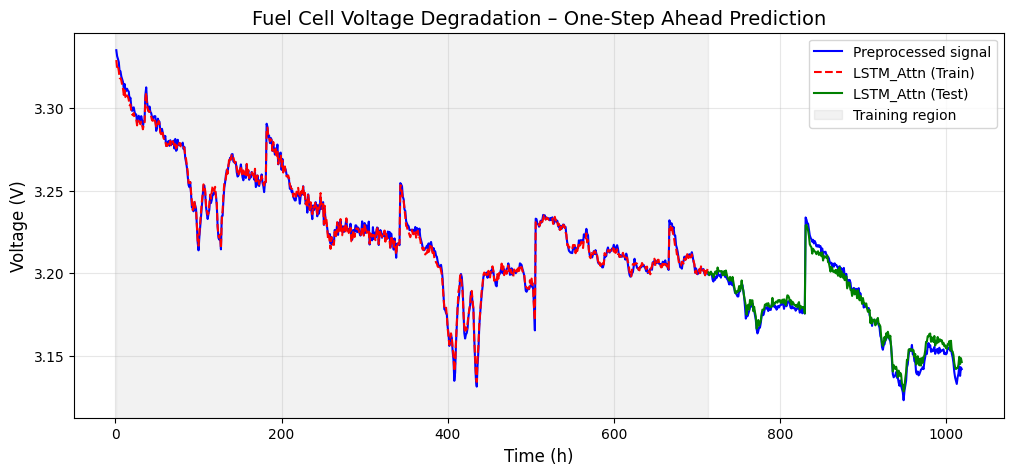

In [16]:
device = torch.device("cpu")
model = model.to(device)
model.eval()
Xtrain_torch = torch.tensor(Xtr, dtype=torch.float32).to(device)
Xtest_torch = torch.tensor(Xts, dtype=torch.float32).to(device)

with torch.no_grad():
    pred_train = model(Xtrain_torch).cpu().numpy()
    pred_test = model(Xtest_torch).cpu().numpy()

pred_train = scaler_y.inverse_transform(pred_train)
pred_test = scaler_y.inverse_transform(pred_test)

plot_pytorch( DF, len(Xtr), pred_train, pred_test, name="LSTM_Attn", save_name="BZ100_2_LSTM_TF_1step",
              title="One-Step Ahead Prediction")

## Long-Term Forecast

Perform recursive forecasting by feeding previous predictions back into the model.

In [17]:
def recursive_forecast_pt(model, Xtest, scaler_x, scaler_y, device="cpu"):
    model.eval()
    model = model.to(device)
    
    
    preds_unscaled = []
    for i in range(len(Xtest)):

        if i==0:
            x_input = Xtest[0]
        else:
            x_input = scaler_x.inverse_transform(Xtest[i])
            x_input[0][1]= preds_unscaled[-1]
            x_input = scaler_x.transform(x_input)
        
        xt = torch.tensor(x_input, dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            yhat_scaled = model(xt).cpu().numpy()

        yhat_unscaled = scaler_y.inverse_transform(yhat_scaled)
        preds_unscaled.append(yhat_unscaled[0, 0])
        
        
    return preds_unscaled

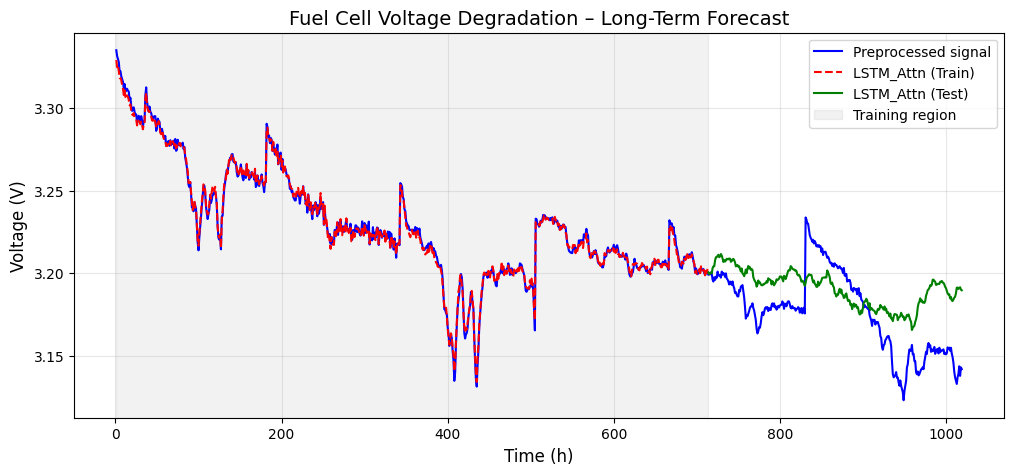

In [18]:
LT_pred = recursive_forecast_pt(model,Xts, scaler_x, scaler_y)

plot_pytorch(DF, len(Xtr), pred_train, LT_pred, name="LSTM_Attn", save_name="BZ100_2_LSTM_TF_LT",
              title="Long-Term Forecast")

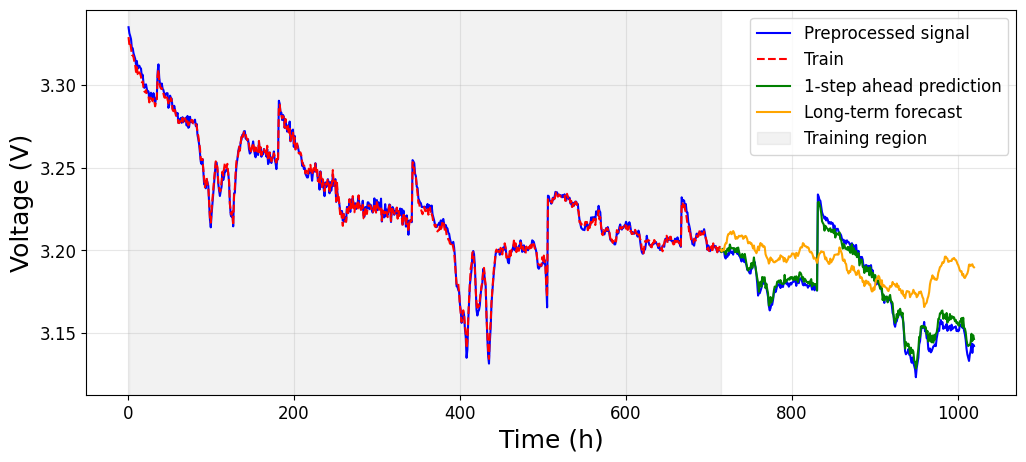

In [19]:
plt.figure(figsize=(12, 5))
plt.style.use("default")
# Experimental data

plt.plot(DF['T(h)'], DF['Utot (V)'], color='blue', label='Preprocessed signal')

# Train predictions
plt.plot( DF[:len(Xtr)]['T(h)'], pred_train, color='red', linestyle='--', linewidth=1.5, label='Train')

# Test predictions 
plt.plot( DF[len(Xtr):]['T(h)'], pred_test, color='green', linewidth=1.5, label= '1-step ahead prediction')
plt.plot( DF[len(Xtr):]['T(h)'], LT_pred, color='orange', linewidth=1.5, label= 'Long-term forecast')



# Mark training region
split_time = DF['T(h)'].iloc[len(Xtr)]
plt.axvspan(DF['T(h)'].iloc[0], split_time, color='gray', alpha=0.1, label='Training region')

plt.xlabel("Time (h)", fontsize=18)
plt.ylabel("Voltage (V)", fontsize=18)
#plt.title("Fuel Cell Voltage Prediction", fontsize=14)
plt.tick_params(axis='both', colors='black', labelsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
#plt.savefig("BZ100_2_LSTMATTn_AllOP.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

## Model Evaluation

Evaluate the model performance on the training and test sets using MSE, RMSE, MAE, and R² metrics.

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def regression_metrics(y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return mse, rmse, mae, r2

y_train_true = DF[:len(Xtr)]['Utot (V)']   # or whatever your true training target is
y_train_pred = pred_train

mse_tr, rmse_tr, mae_tr, r2_tr = regression_metrics(y_train_true, y_train_pred)

print("TRAINING METRICS")
print(f"MSE  : {mse_tr:.4f}")
print(f"RMSE : {rmse_tr:.4f}")
print(f"MAE  : {mae_tr:.4f}")
print(f"R²   : {r2_tr:.4f}")

TRAINING METRICS
MSE  : 0.0000
RMSE : 0.0021
MAE  : 0.0016
R²   : 0.9962


In [21]:
y_test_true = DF[len(Xtr):]['Utot (V)']
mse_1, rmse_1, mae_1, r2_1 = regression_metrics(y_test_true, pred_test)

print("\n1-STEP AHEAD")
print(f"MSE  : {mse_1:.4f}")
print(f"RMSE : {rmse_1:.4f}")
print(f"MAE  : {mae_1:.4f}")
print(f"R²   : {r2_1:.4f}")


mse_LT, rmse_LT, mae_LT, r2_LT = regression_metrics(y_test_true, LT_pred)

print("\nLong term prediction")
print(f"MSE  : {mse_LT:.4f}")
print(f"RMSE : {rmse_LT:.4f}")
print(f"MAE  : {mae_LT:.4f}")
print(f"R²   : {r2_LT:.4f}")




1-STEP AHEAD
MSE  : 0.0000
RMSE : 0.0037
MAE  : 0.0031
R²   : 0.9768

Long term prediction
MSE  : 0.0006
RMSE : 0.0250
MAE  : 0.0216
R²   : -0.0547
